In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv('/home/moosaabbasi/ml/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#EDA

In [14]:
df.shape

(1338, 7)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [16]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

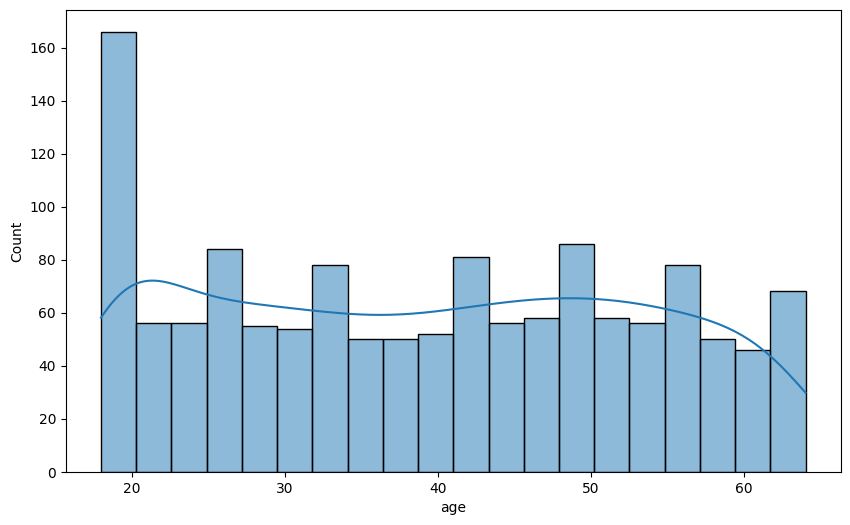

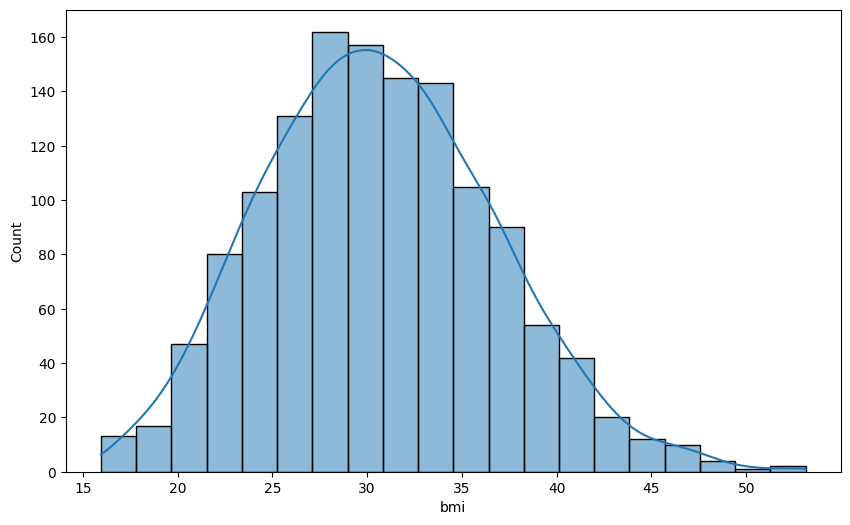

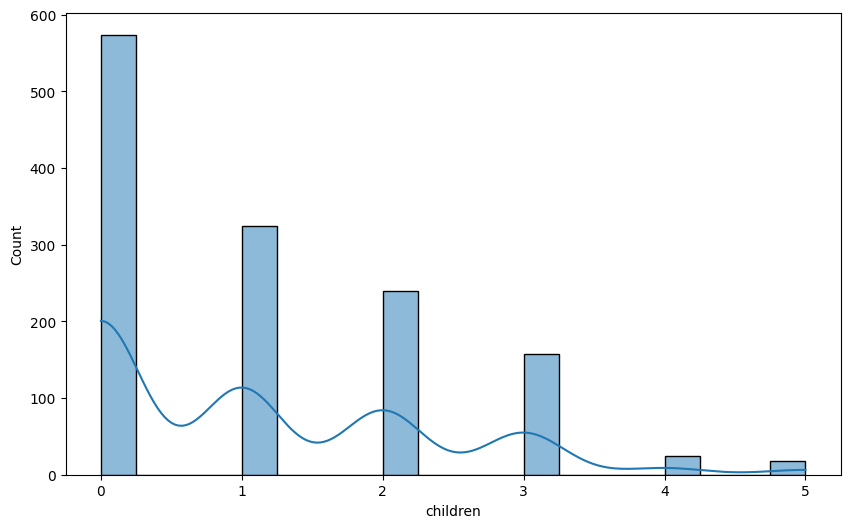

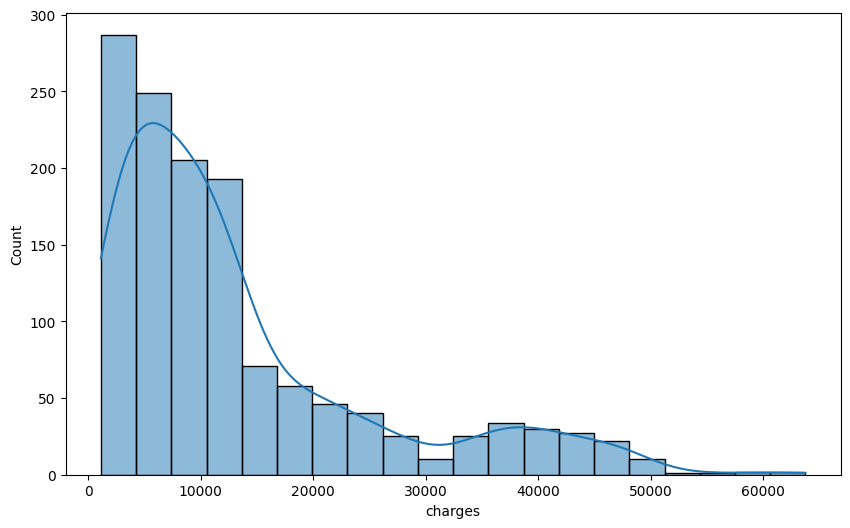

In [18]:
numeric_col = ['age','bmi','children','charges']
for col in numeric_col:
   plt.figure(figsize = (10,6))
   sns.histplot(df[col], kde=True , bins=20)

<Axes: xlabel='children', ylabel='count'>

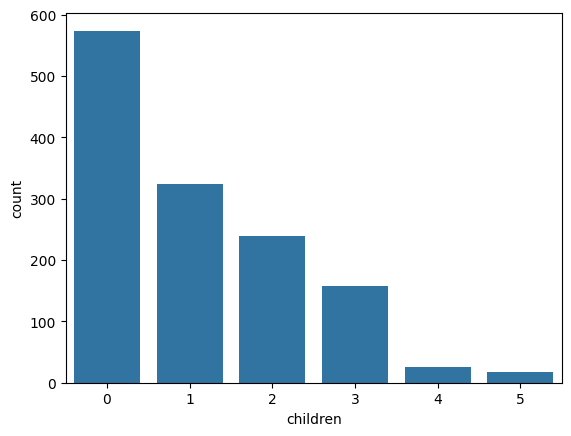

In [19]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

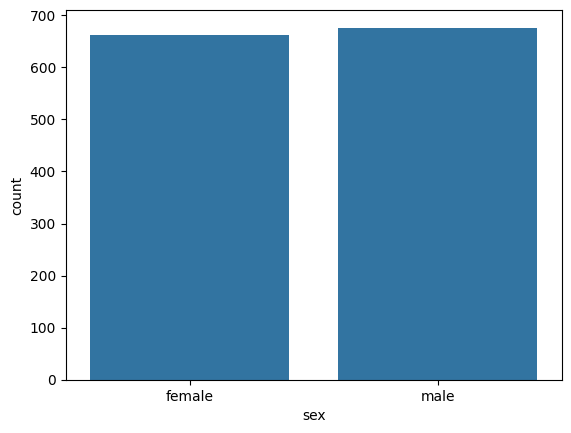

In [20]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

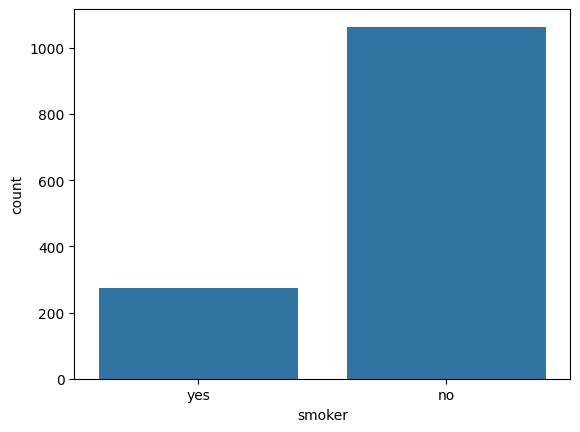

In [21]:
sns.countplot(x = df['smoker'])

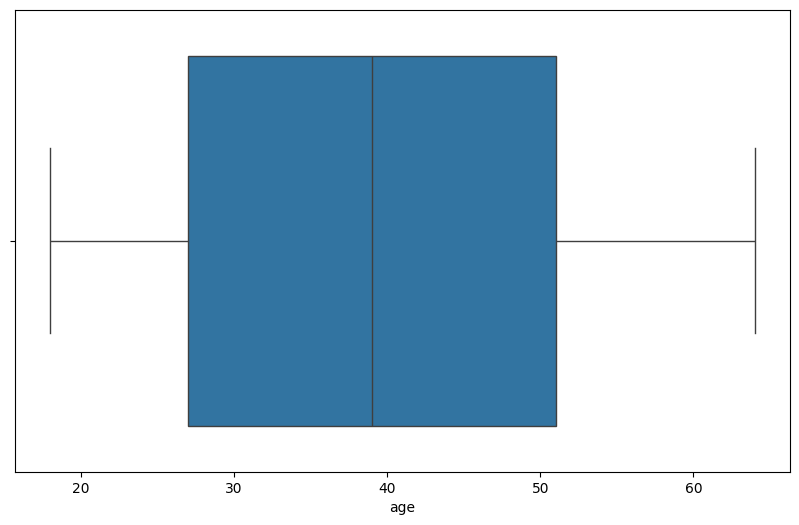

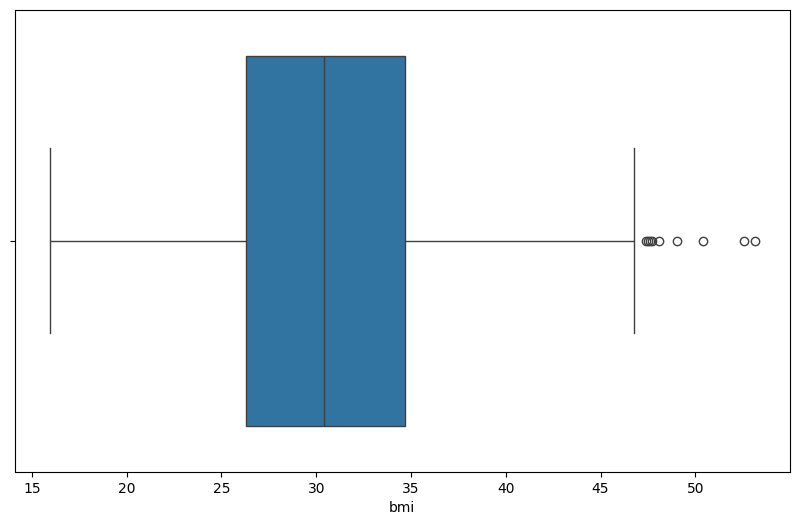

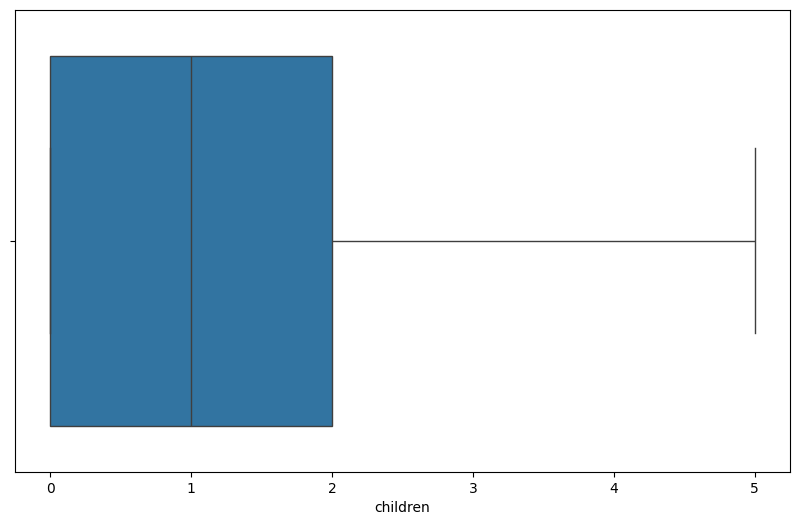

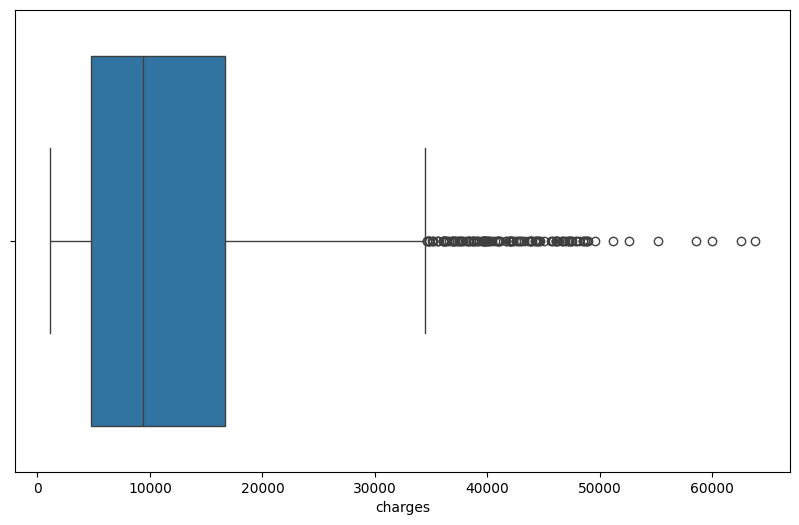

In [22]:
for col in numeric_col:
  plt.figure(figsize=(10,6))
  sns.boxplot(x = df[col])

<Axes: >

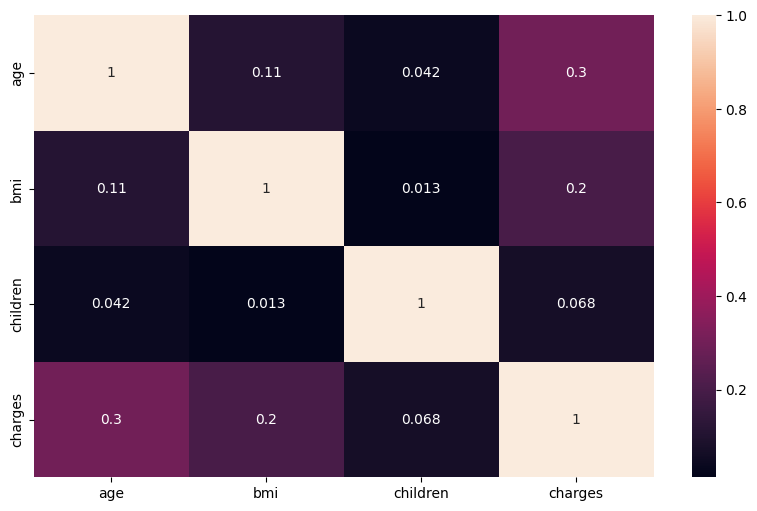

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

#Data Cleaning and preprocessing

In [24]:
df_copy = df.copy()
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [25]:
df_copy.reset_index
df_copy.shape

(1338, 7)

In [26]:
df_copy.drop_duplicates(inplace=True)
df_copy.shape

(1337, 7)

In [27]:
df_copy.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [28]:
df_copy.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [29]:
print(df_copy['sex'].value_counts())
print(df_copy['smoker'].value_counts())
print(df_copy['region'].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [30]:
#label encoding
df_copy['sex'] = df_copy['sex'].map({"male" : 0 , "female":1})
df_copy['smoker'] = df_copy['smoker'].map({"yes":0 , "no":1})

#one hot encoding
df_copy = pd.get_dummies(df_copy , columns=['region'],drop_first=True,dtype =float)

In [31]:
df_copy.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,0,16884.92400,0.0,0.0,1.0
1,18,0,33.770,1,1,1725.55230,0.0,1.0,0.0
2,28,0,33.000,3,1,4449.46200,0.0,1.0,0.0
3,33,0,22.705,0,1,21984.47061,1.0,0.0,0.0
4,32,0,28.880,0,1,3866.85520,1.0,0.0,0.0


In [32]:
df_copy.rename(columns={'sex' : 'Gender'},inplace=True)
df_copy.head()

,age,Gender,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,0,16884.92400,0.0,0.0,1.0
1,18,0,33.770,1,1,1725.55230,0.0,1.0,0.0
2,28,0,33.000,3,1,4449.46200,0.0,1.0,0.0
3,33,0,22.705,0,1,21984.47061,1.0,0.0,0.0
4,32,0,28.880,0,1,3866.85520,1.0,0.0,0.0


In [33]:
df_copy = df_copy.astype(int)

In [34]:
df_copy

,age,Gender,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,0,16884,0,0,1
1,18,0,33,1,1,1725,0,1,0
2,28,0,33,3,1,4449,0,1,0
3,33,0,22,0,1,21984,1,0,0
4,32,0,28,0,1,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0
1334,18,1,31,0,1,2205,0,0,0
1335,18,1,36,0,1,1629,0,1,0
1336,21,1,25,0,1,2007,0,0,1


#feature Engineering and extracton

<Axes: xlabel='bmi', ylabel='Count'>

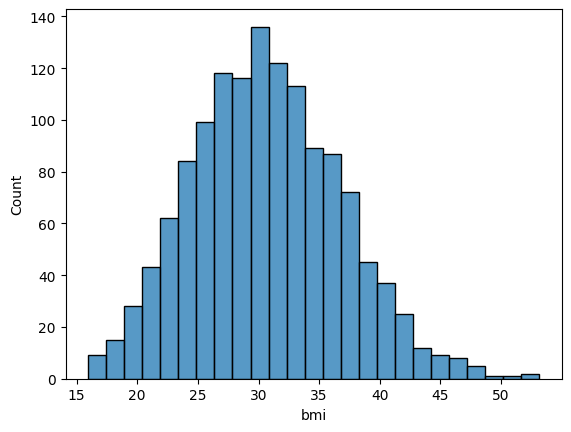

In [35]:
sns.histplot(df['bmi'])

In [36]:
ages = np.array([5, 15, 25, 35, 45, 55, 65, 75])

bins = [0,10,20,50,60]
# To match the 4 intervals created by 5 bins, we need 4 labels.
label = ['child' , 'young' , 'youth' , 'middle']

new = pd.cut(ages , bins=bins ,labels=label)
print(new)

['child', 'young', 'youth', 'youth', 'youth', 'middle', NaN, NaN]
Categories (4, str): ['child' < 'young' < 'youth' < 'middle']


In [37]:
df_copy['bmi_catagorey'] = pd.cut(
    df_copy['bmi'],
    bins=[0,18.5,24.9,29.9 , float('inf')],
    labels=['under_weight','Normal','Over_weight','obeese']
)
df_copy

,age,Gender,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_catagorey
0,19,1,27,0,0,16884,0,0,1,Over_weight
1,18,0,33,1,1,1725,0,1,0,obeese
2,28,0,33,3,1,4449,0,1,0,obeese
3,33,0,22,0,1,21984,1,0,0,Normal
4,32,0,28,0,1,3866,1,0,0,Over_weight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0,obeese
1334,18,1,31,0,1,2205,0,0,0,obeese
1335,18,1,36,0,1,1629,0,1,0,obeese
1336,21,1,25,0,1,2007,0,0,1,Over_weight


In [38]:
df_copy = pd.get_dummies(df_copy , columns=['bmi_catagorey'],drop_first=True,dtype =float)
df_copy=df_copy.astype(int)
df_copy.head()

,age,Gender,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_catagorey_Normal,bmi_catagorey_Over_weight,bmi_catagorey_obeese
0,19,1,27,0,0,16884,0,0,1,0,1,0
1,18,0,33,1,1,1725,0,1,0,0,0,1
2,28,0,33,3,1,4449,0,1,0,0,0,1
3,33,0,22,0,1,21984,1,0,0,1,0,0
4,32,0,28,0,1,3866,1,0,0,0,1,0


In [39]:
df_copy.columns

Index(['age', 'Gender', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_catagorey_Normal', 'bmi_catagorey_Over_weight',
       'bmi_catagorey_obeese'],
      dtype='str')

In [40]:
from sklearn.preprocessing import StandardScaler
col = ['age','bmi','children']
scale = StandardScaler()

df_copy[col] = scale.fit_transform(df_copy[col])

In [41]:
df_copy

,age,Gender,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_catagorey_Normal,bmi_catagorey_Over_weight,bmi_catagorey_obeese
0,-1.440418,1,-0.517949,-0.909234,0,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,1,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,1,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,1,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,1,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,1,2007,0,0,1,0,1,0


#extraction


In [42]:
from scipy.stats import pearsonr
selected_column = ['age', 'Gender', 'bmi', 'children', 'smoker', 'charges','region_northwest', 'region_southeast', 'region_southwest','bmi_catagorey_Normal', 'bmi_catagorey_Over_weight','bmi_catagorey_obeese']

corelation = {
     feature:pearsonr(df_copy[feature],df_copy['charges'])[0]
     for feature in selected_column
}

coorelation_df = pd.DataFrame(list(corelation.items()),columns=['feature','pearson corealtion'])
coorelation_df.sort_values(by='pearson corealtion',ascending=False)

,feature,pearson corealtion
5,charges,1.000000
0,age,0.298309
11,bmi_catagorey_obeese,0.200348
2,bmi,0.196236
7,region_southeast,0.073577
3,children,0.067390
6,region_northwest,-0.038695
8,region_southwest,-0.043637
1,Gender,-0.058046
9,bmi_catagorey_Normal,-0.104042


In [43]:
cat_selected=['Gender','smoker','region_northwest', 'region_southeast', 'region_southwest','bmi_catagorey_Normal', 'bmi_catagorey_Over_weight','bmi_catagorey_obeese']



In [44]:
from scipy.stats import chi2_contingency

alpha = 0.05
df_copy['charges bin']=pd.qcut(df_copy['charges'],q=4,labels=['Low', 'Medium', 'High', 'Very High'])
chi2_results={}

for col in cat_selected:
  contingency = pd.crosstab(df_copy[col],df_copy['charges bin'])

  chi2_stat , p_val ,_,_= chi2_contingency(contingency)
  decision = 'Reject Null (keep Feature)' if p_val < alpha else 'Accpet Null (drop feature)'
  chi2_results[col] = {
      'chi2_statisticts':chi2_stat,
      'p_value': p_val,
      'Decision': decision
  }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by = 'p_value')
chi2_df


,chi2_statisticts,p_value,Decision
smoker,848.219178,0.0,Reject Null (keep Feature)
region_southeast,15.998167,0.001135,Reject Null (keep Feature)
Gender,10.258784,0.01649,Reject Null (keep Feature)
bmi_catagorey_obeese,8.515711,0.036473,Reject Null (keep Feature)
region_southwest,5.091893,0.165191,Accpet Null (drop feature)
bmi_catagorey_Over_weight,4.25149,0.235557,Accpet Null (drop feature)
bmi_catagorey_Normal,3.708088,0.29476,Accpet Null (drop feature)
region_northwest,1.13424,0.768815,Accpet Null (drop feature)


In [45]:
final_df = df_copy[['age', 'Gender', 'bmi', 'children', 'smoker', 'charges',
'region_southeast','bmi_catagorey_obeese']]
final_df

,age,Gender,bmi,children,smoker,charges,region_southeast,bmi_catagorey_obeese
0,-1.440418,1,-0.517949,-0.909234,0,16884,0,0
1,-1.511647,0,0.462463,-0.079442,1,1725,1,1
2,-0.799350,0,0.462463,1.580143,1,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,1,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,1,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,1,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,1,2007,0,0


In [46]:
final_df.to_csv('insurance valuable.csv')